*Built with Grok Build*

# Project 2 — Sonar Mine vs Rock Classification



In [2]:
##########################################################################################
# EEE591_419 Python for Rapid Engineering Solutions - Project 2: proj.py
# Mark Khusid
##########################################################################################

##########################################################################################
# Project 2 
##########################################################################################


### Import Libraries


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Set Debug State


In [4]:
debug = False


## Read Database


In [5]:
df = pd.read_csv("sonar_all_data_2.csv", header=None)


In [6]:
if debug:
    print(df.head(10))


In [7]:
if debug:
    print(df.tail(10))


## Separate Data into Features and Classes


In [8]:
X = df.iloc[:, :-2].values  # Last two columns are labels
y = df.iloc[:, -1].values # Use last column because it is numeric


## Exploratory Data Analysis on Database


### Find Number of Rows with Missing Data


In [9]:
if debug:
    print("Shape:", df.shape)
    print("\nMissing values:")
    print(df.isnull().sum())


### Descriptive Statistics Table of All Features


In [10]:
#df.describe()


In [11]:
#df.info()


### Create Box Plots of Features


In [12]:
# Remove the label columns (last 2 columns)
X_boxplots = df.iloc[:, :-2]

# Convert from wide format to long format
X_long = X_boxplots.melt(var_name="Feature", value_name="Value")

if debug:
    print(X_long[:20])
    print()
    print(X_long[-20:])


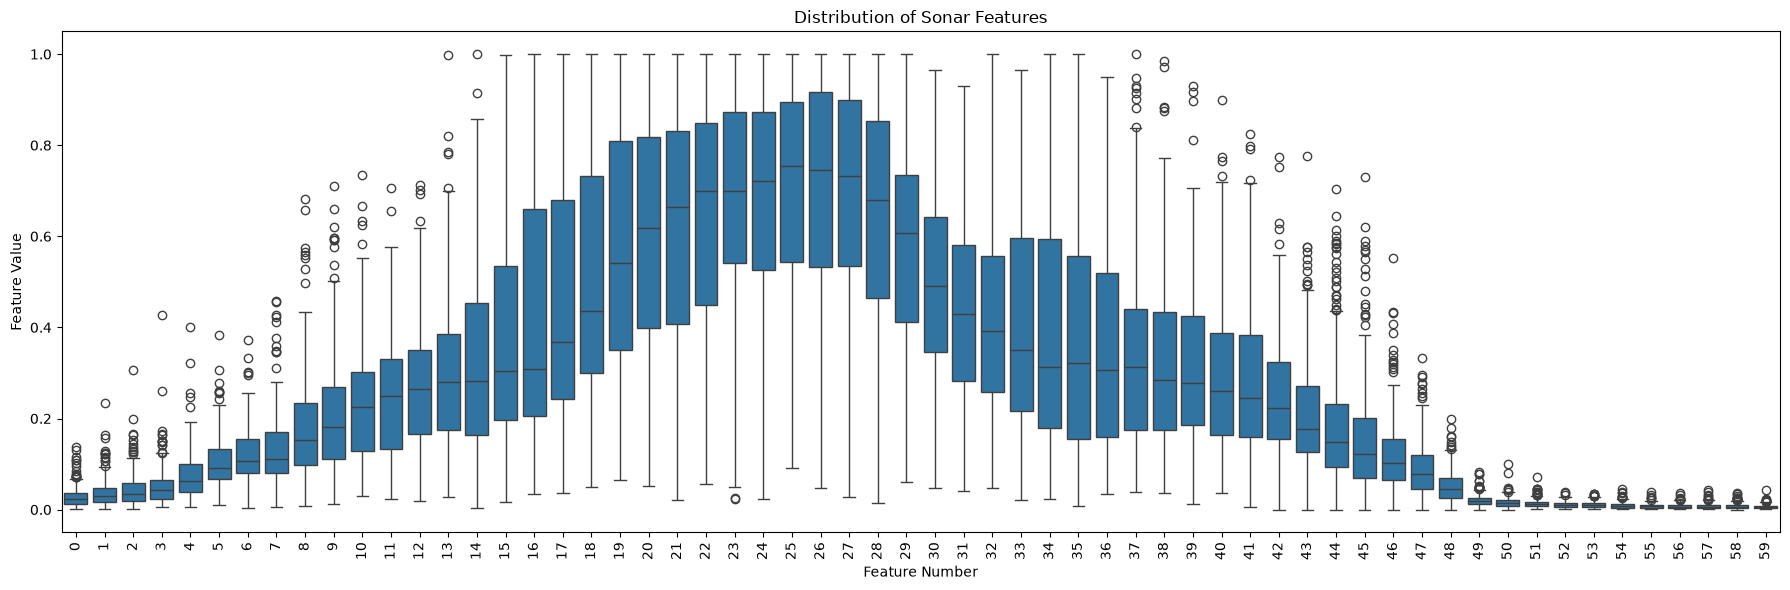

In [13]:
# Create boxplots
plt.figure(figsize=(18, 6))
sns.boxplot(
    data=X_long,
    x="Feature",
    y="Value"
)

plt.title("Distribution of Sonar Features")
plt.xlabel("Feature Number")
plt.ylabel("Feature Value")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()


Most of the energy is in rows 16 to 33.  Data is range between 1 and 0.


### Create Histogram of Every Feature


In [14]:
# Feature columns only
X = df.iloc[:, :60]

if debug:
    print(X.iloc[:3])


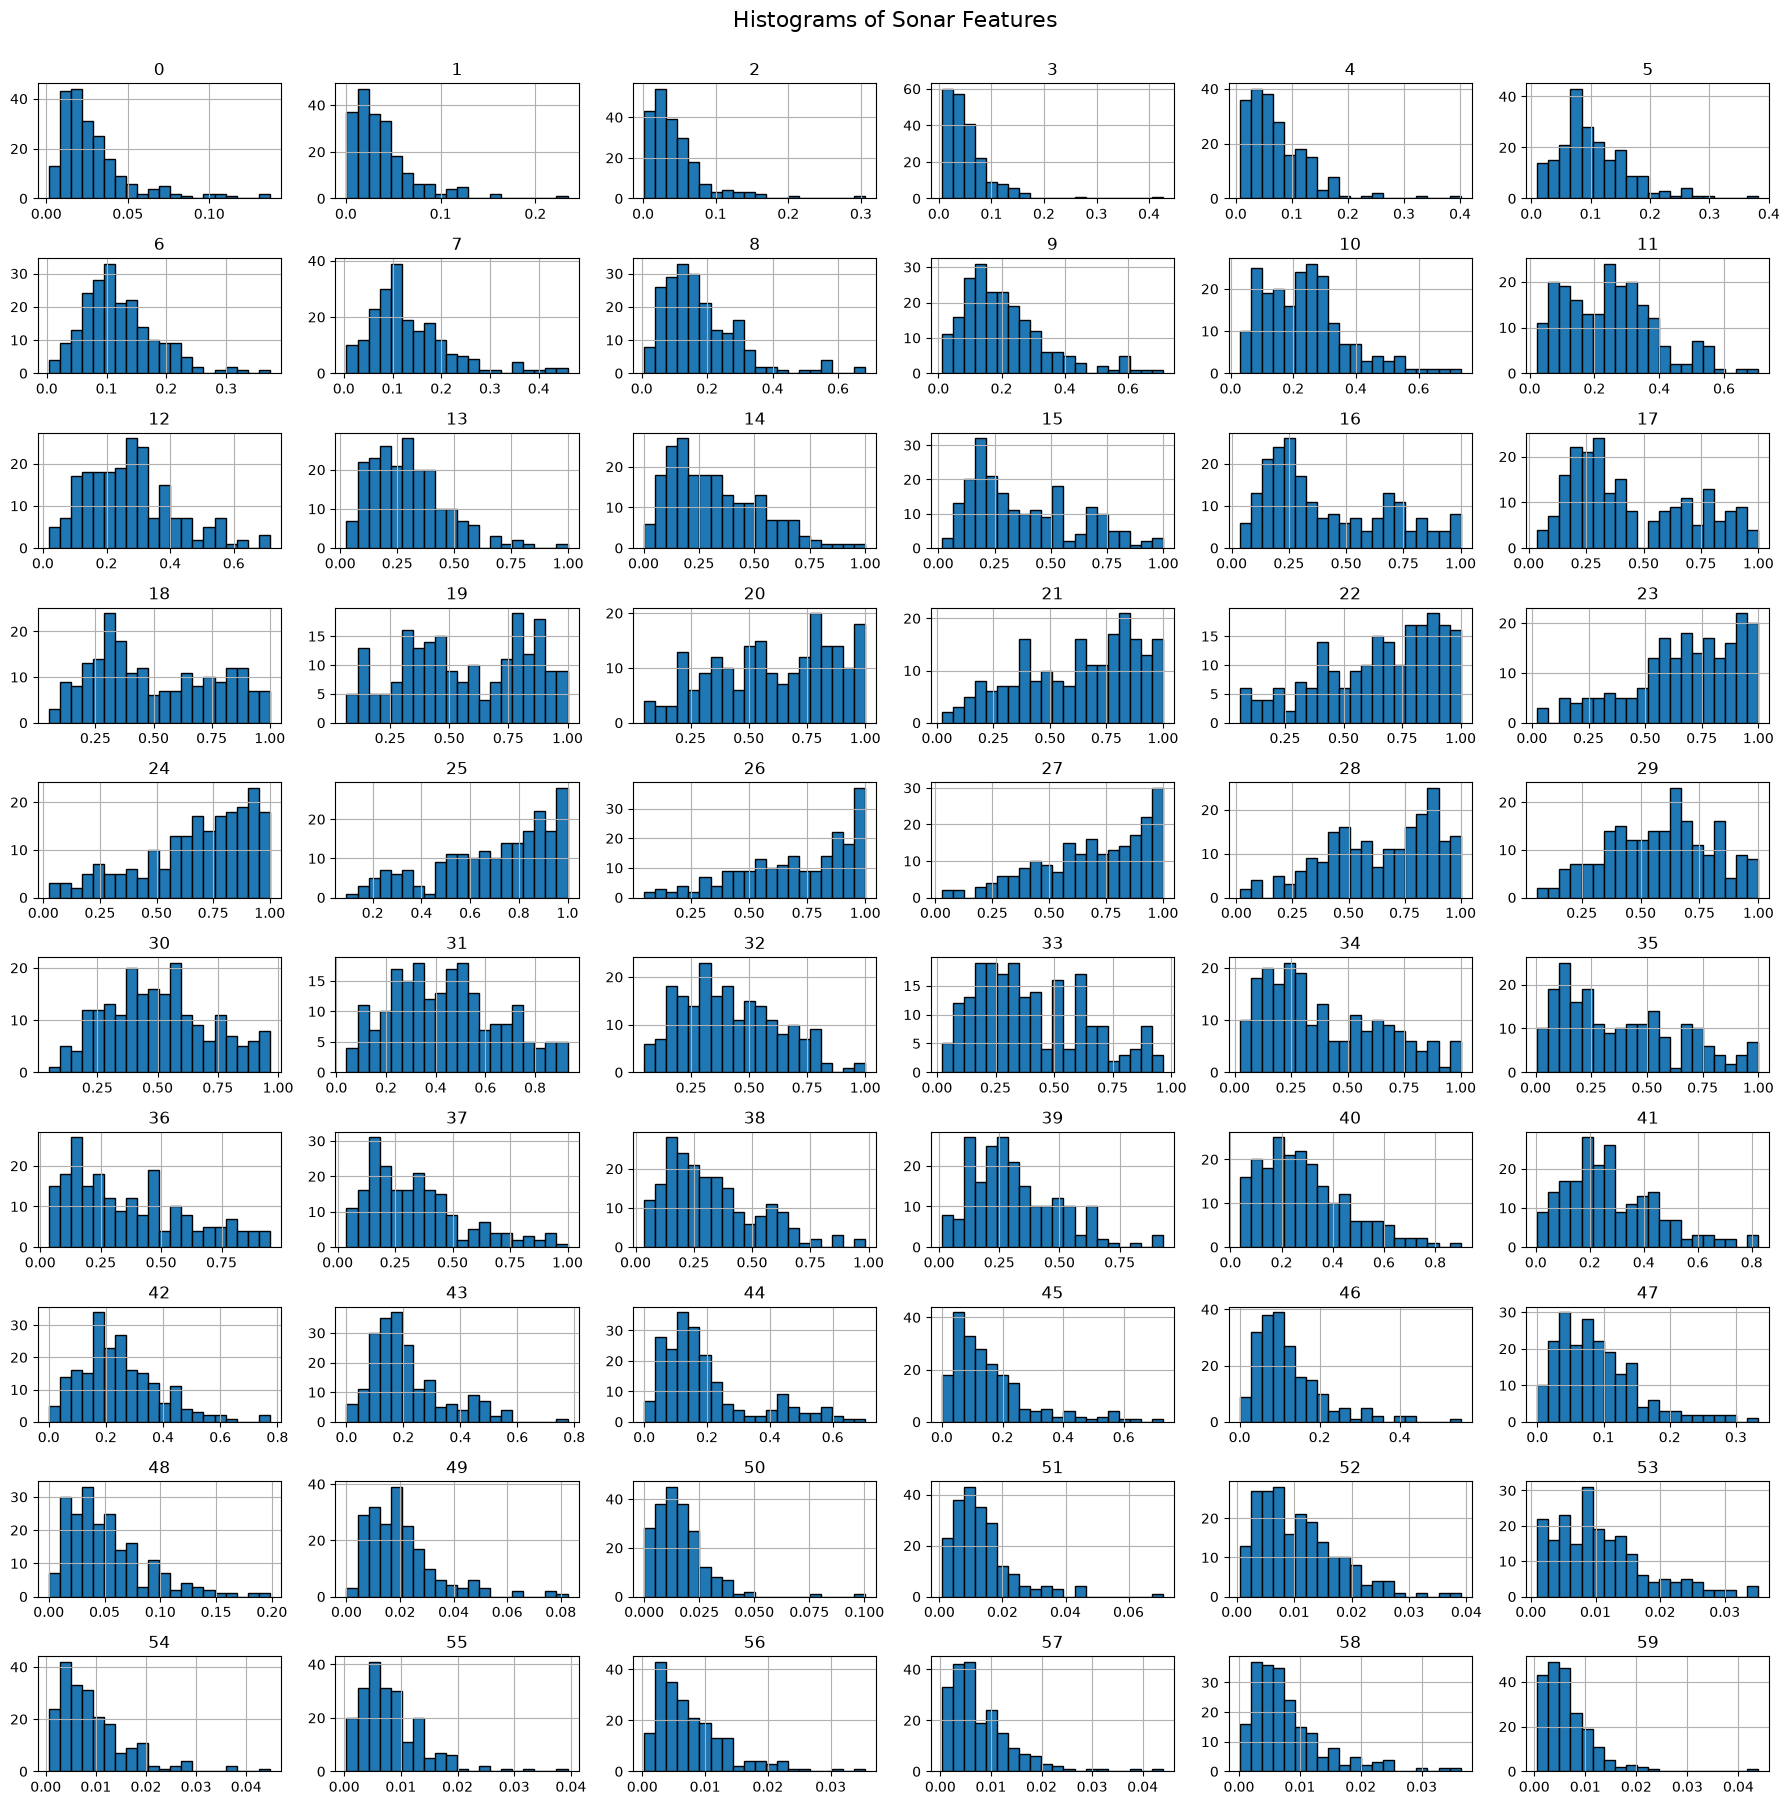

In [15]:
X.hist(
    bins=20,
    figsize=(18, 18),
    layout=(10, 6),   # 10 rows x 6 columns = 60 plots
    edgecolor='black'
)

plt.suptitle("Histograms of Sonar Features", fontsize=16, y=1.0)
plt.tight_layout()
plt.show()


Skewness varies along intervals.


### Create Heatmap of Every Feature


In [16]:
X_df = pd.DataFrame(X_boxplots)

if debug:
    print(X_df.iloc[:3])


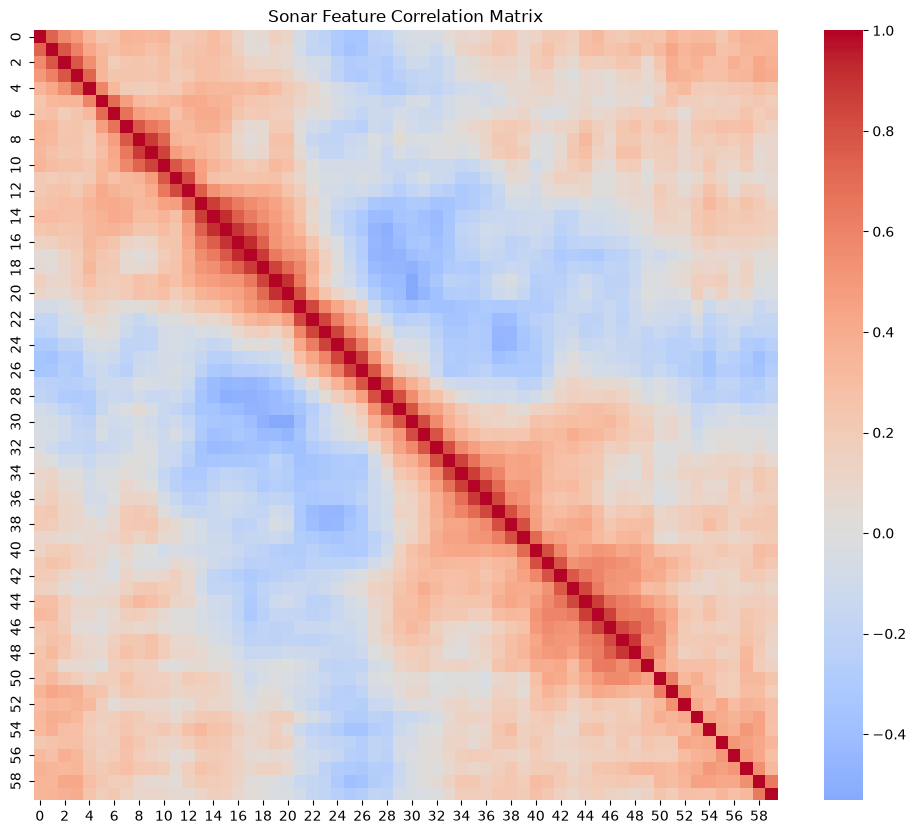

In [17]:
corr = X_df.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', center=0)

plt.title("Sonar Feature Correlation Matrix")
plt.show()


Strong adjacent correlations


### Examine Class Label Distribution


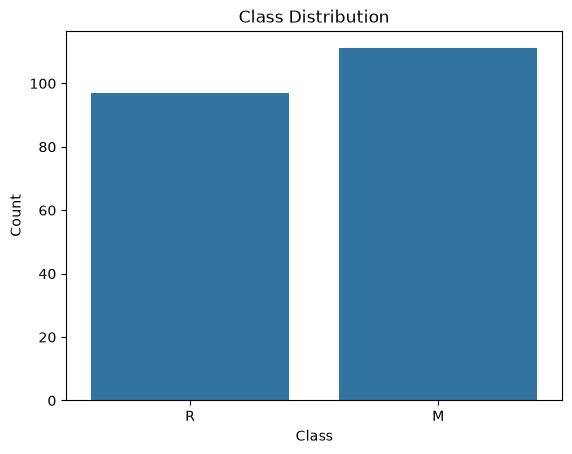

In [18]:
sns.countplot(x=df.iloc[:, 61])

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


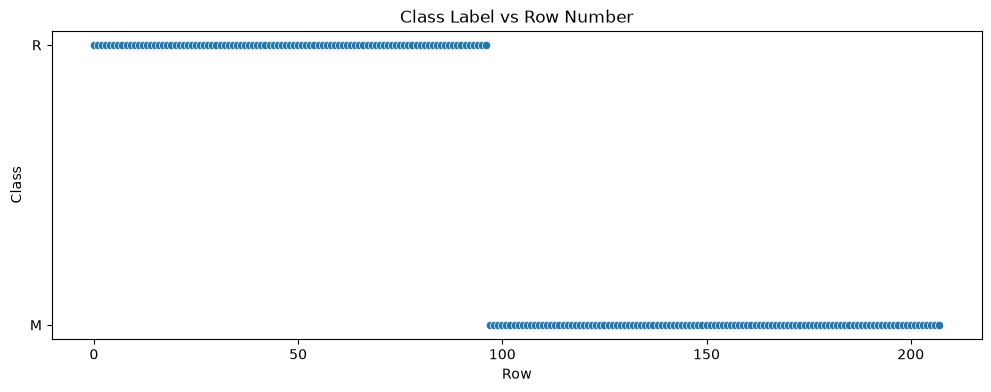

In [19]:
plot_df = pd.DataFrame({
    'Row': np.arange(len(df)),
    'Class': df.iloc[:, 61]
})

plt.figure(figsize=(12,4))

sns.scatterplot(
    data=plot_df,
    x='Row',
    y='Class'
)

plt.title('Class Label vs Row Number')
plt.show()


## Process Labels


### Convert String Labels into Numbers


In [20]:
if debug:
    print(y[0:10])


In [21]:
if debug:
    print(y[-10:])


In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# R -> 1
# M -> 0


In [23]:
if debug:
    print(y_encoded[0:20])


In [24]:
if debug:
    print(y_encoded[-20:])


## Train / Test Split


In [25]:
# Shuffeling is required because the labels are not in random order


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=0,
    stratify=y
)


In [27]:
if debug:
    print(X_train[0:10])


In [28]:
if debug:
    print(y_train[0:10])


## Scale the Data using StandardScaler


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)


In [30]:
if debug:
    print(X_train_std[0:1])


In [31]:
if debug:
    print(X_test_std[0:1])


## Perform PCA on Variable Number of Components


In [32]:
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

def run_one_pca_model(ncomp, seed):

    pca = PCA(n_components=ncomp)

    X_train_pca = pca.fit_transform(X_train_std)
    X_test_pca = pca.transform(X_test_std)

    model = MLPClassifier(
        hidden_layer_sizes=(100,),
        activation='logistic',
        max_iter=20000,
        alpha=1e-5,
        solver='adam',
        random_state=seed
    )

    model.fit(X_train_pca, y_train)

    predictions = model.predict(X_test_pca)
    acc = accuracy_score(y_test, predictions)

    return ncomp, acc, predictions


### Create Function to Parallelize


In [33]:
from joblib import Parallel, delayed

def run_seed(seed):

    results = Parallel(n_jobs=8, verbose=0)(
        delayed(run_one_pca_model)(ncomp, seed)
        for ncomp in range(1, 61)
    )

    return seed, results


In [34]:
#accuracies = []
#best_accuracy = 0
#best_components = 0
#best_predictions = None

#for ncomp, acc, predictions in results:
#    accuracies.append(acc)

#    if debug:
#        print(f"Components={ncomp:2d} Accuracy={acc:.4f}")

#    if acc > best_accuracy:
#        best_accuracy = acc
#        best_components = ncomp
#        best_predictions = predictions

#print("\nBest Result")
#print(f"Best Components = {best_components}")
#print(f"Best Accuracy   = {best_accuracy:.4f}")


In [35]:
# List of random seeds to test.
# Using a variety of small + larger seeds helps check stability across different data splits.
seeds = [0, 1, 2, 3, 4, 5, 10]

# Container to store the final summary for every seed
all_results = []

print('****** Initiating Paraellel Computation (8 cores) ******')
print()

# === Main loop over seeds ===
for seed in seeds:

    # Call the function that runs all n_components for this particular seed.
    seed, results = run_seed(seed)

    # Initialize variables to track the best configuration for this seed
    best_ncomp = None
    best_acc = 0
    best_predictions = None

    # Iterate through all (n_components, accuracy) pairs returned for this seed
    for ncomp, acc, predictions in results:

        # Keep track of the highest accuracy and its corresponding number of components
        if acc > best_acc:
            best_acc = acc
            best_ncomp = ncomp
            best_predictions = predictions

    # Store a structured record for this seed
    all_results.append(
        {
            "seed": seed,
            "best_ncomp": best_ncomp,
            "best_acc": best_acc,
            "best_predictions": best_predictions,
            "results": results # full list of all (ncomp, acc) pairs
        }
    )

    # Print a nice one-line summary for this seed
    print(
        f"Seed = {seed:3d},  "
        f"Best Components = {best_ncomp:2d}, "
        f"Accuracy = {best_acc:.4f}"
    )

print()
print('***** Parallel Computations Complete ******')


****** Initiating Paraellel Computation (8 cores) ******



Seed =   0,  Best Components = 13, Accuracy = 0.9206


Seed =   1,  Best Components = 16, Accuracy = 0.9365


Seed =   2,  Best Components = 16, Accuracy = 0.9365


Seed =   3,  Best Components = 16, Accuracy = 0.9206


Seed =   4,  Best Components = 17, Accuracy = 0.9365


Seed =   5,  Best Components = 16, Accuracy = 0.9365


Seed =  10,  Best Components = 17, Accuracy = 0.9365

***** Parallel Computations Complete ******


## Find the Best Seed Results


In [36]:
# Find the result with the highest best_acc
best_seed_result = max(
    all_results,
    key=lambda x: x["best_acc"]
)

print()
print(f"Best Seed: {best_seed_result['seed']}")
print(f"Best Number of Compnents: {best_seed_result['best_ncomp']}")
print(f"Best Accuracy: {best_seed_result['best_acc']:.4f}")   



Best Seed: 1
Best Number of Compnents: 16
Best Accuracy: 0.9365


## Plot the Results


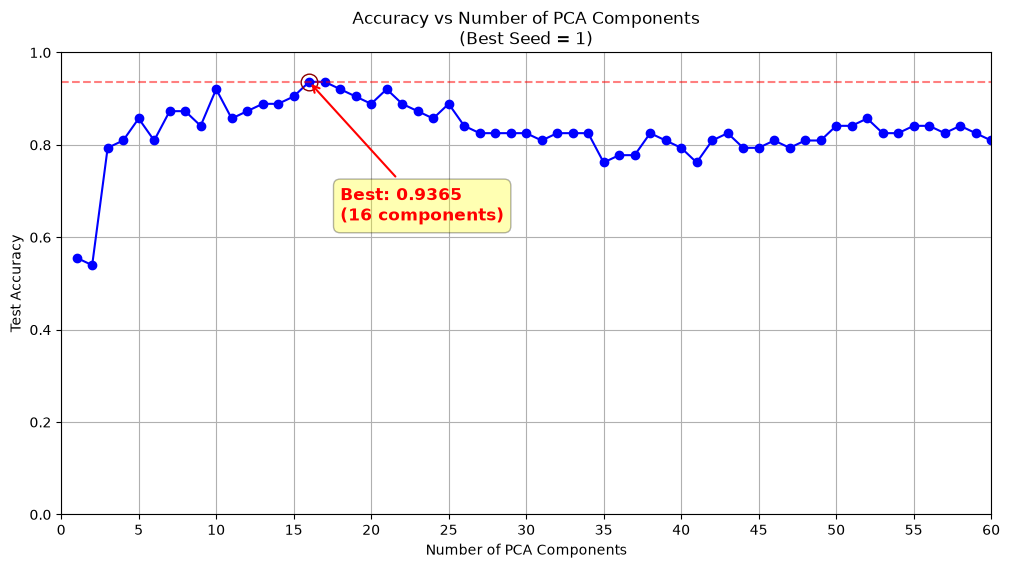

Best seed: 1
Best accuracy: 0.9365 using 16 PCA components


In [37]:
import matplotlib.pyplot as plt
import numpy as np

# Get results for the best seed
results = best_seed_result["results"]

# Extract component counts and accuracies
ncomps = np.array([r[0] for r in results])
accuracies = np.array([r[1] for r in results])

# Find best accuracy
best_idx = np.argmax(accuracies)
best_ncomp = ncomps[best_idx]
best_acc = accuracies[best_idx]

plt.figure(figsize=(12, 6))

plt.plot(
    ncomps,
    accuracies,
    marker='o',
    linestyle='-',
    color='blue'
)

# Highlight best point
plt.plot(
    best_ncomp,
    best_acc,
    marker='o',
    markersize=12,
    color='red',
    markeredgecolor='darkred',
    markerfacecolor='none',
    linewidth=2
)

# Annotate best point
plt.annotate(
    f'Best: {best_acc:.4f}\n({best_ncomp} components)',
    xy=(best_ncomp, best_acc),
    xytext=(best_ncomp + 2, best_acc - 0.3),
    fontsize=12,
    fontweight='bold',
    color='red',
    arrowprops=dict(
        arrowstyle='->',
        color='red',
        lw=1.5
    ),
    bbox=dict(
        boxstyle='round,pad=0.4',
        facecolor='yellow',
        alpha=0.3
    )
)

plt.xlabel("Number of PCA Components")
plt.ylabel("Test Accuracy")
plt.title(
    f"Accuracy vs Number of PCA Components\n"
    f"(Best Seed = {best_seed_result['seed']})"
)

plt.ylim(0, 1)
plt.xlim(1, 60)
plt.xticks(np.arange(0, 61, 5))
plt.grid(True)

# Optional
plt.axhline(
    y=best_acc,
    color='red',
    linestyle='--',
    alpha=0.5
)

plt.show()

print(
    f"Best seed: {best_seed_result['seed']}"
)
print(
    f"Best accuracy: {best_acc:.4f} "
    f"using {best_ncomp} PCA components"
)


## Create Confusion Matrix


In [38]:
best_predictions = best_seed_result["best_predictions"]


In [39]:
if debug:
    print(best_predictions)


In [40]:
print(len(best_predictions))


63


In [41]:
if debug:
    print(y_test)


In [42]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, best_predictions)

print("\nConfusion Matrix")
print(cm)



Confusion Matrix
[[32  2]
 [ 2 27]]


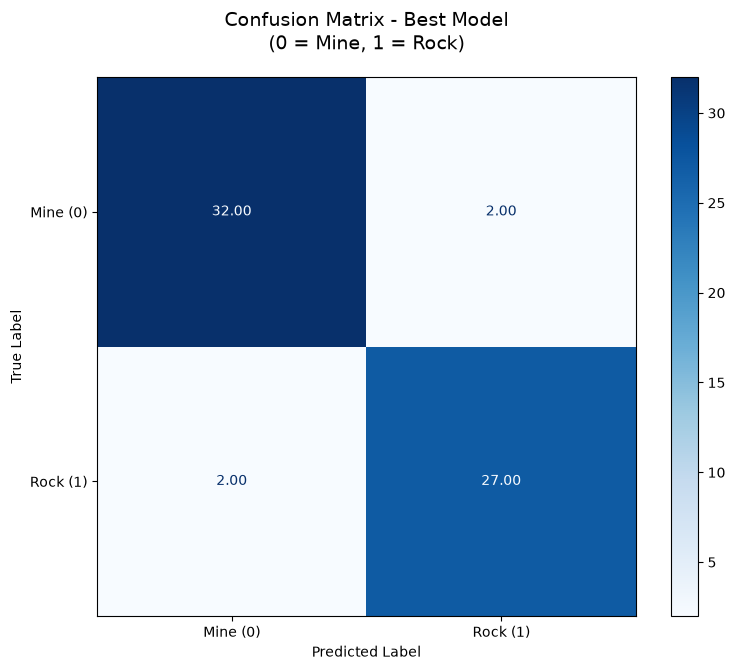

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, best_predictions)

# Create display with nice formatting
fig, ax = plt.subplots(figsize=(9, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Mine (0)', 'Rock (1)']   # 0 = Mine, 1 = Rock
)

disp.plot(ax=ax, cmap='Blues', values_format='.2f')

# Add title and labels
plt.title("Confusion Matrix - Best Model\n(0 = Mine, 1 = Rock)", 
          fontsize=14, pad=20)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()
